In [1]:
import numpy as np
import json

import matplotlib.pyplot as plt

### Подготовка
Подгружаем данные, сплитим, строим граф

In [2]:
SESSION_FILE_PATH = "sessions.jsonl"

In [3]:
def sessions_list() -> list[list[int]]:
    sessions = []
    with open(SESSION_FILE_PATH, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            sessions.append(json.loads(line))

    return sessions

In [4]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

In [5]:
sessions = sessions_list()
train, test = train_test_split(sessions)
print(train[0], test[0])

[380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341] 293


In [6]:
def produce_graph(sessions: list[list[int]]) -> dict[int, dict[int, float]]:
    graph = {}
    for session in sessions:
        for i in range(len(session) - 1):
            current_item = session[i]
            next_item = session[i + 1]
            if current_item not in graph:
                graph[current_item] = {}
            if next_item not in graph[current_item]:
                graph[current_item][next_item] = 0
            graph[current_item][next_item] += 1
    
    for item in graph:
        total_transitions = sum(graph[item].values())
        for next_item in graph[item]:
            graph[item][next_item] /= total_transitions

    return graph

In [7]:
GRAPH: dict[int, dict[int, float]] = produce_graph(train)
print(GRAPH[0])

{262: 0.07692307692307693, 380: 0.38461538461538464, 54: 0.15384615384615385, 114: 0.15384615384615385, 123: 0.07692307692307693, 293: 0.07692307692307693, 308: 0.07692307692307693}


In [8]:
def P(j: int, i: int) -> float:
    if i not in GRAPH or j not in GRAPH[i]:
        return 0
    return GRAPH[i][j]

In [9]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [10]:
def produce_freq_map(sessions: list[list[int]]) -> dict[int, int]:
    freq_map = {}
    for session in sessions:
        for item in session:
            if item not in freq_map:
                freq_map[item] = 0
            freq_map[item] += 1
    return freq_map

### Немного статистик


In [11]:
session_lengths: list[int] = [len(session) for session in sessions]
n_sessions: int = len(sessions)
max_len, min_len, avg_len, sigm_len = max(session_lengths), min(session_lengths), np.mean(session_lengths), np.std(session_lengths)

print(f"Количество сессий: {n_sessions}")
print(f"Макс. длина сессии: {max_len}")
print(f"Мин. длина сессии: {min_len}")
print(f"Средняя длина сессии: {avg_len:.2f}")
print(f"Стандартное отклонение длины сессии: {sigm_len:.2f}")

Количество сессий: 2565
Макс. длина сессии: 20
Мин. длина сессии: 3
Средняя длина сессии: 10.47
Стандартное отклонение длины сессии: 5.90


In [12]:
len_distr: dict[int, int] = {}
for session in  sessions:
    l: int = len(session)
    if l not in len_distr:
        len_distr[l] = 0
    len_distr[l] += 1
freq_distr: dict[int, int] = produce_freq_map(sessions)

In [13]:
n_unique = len(GRAPH.keys())
n_perehodov = sum(session_lengths) - n_sessions

print("Уникальных товаров:", n_unique)
print("Переходов между товарами:", n_perehodov)

Уникальных товаров: 400
Переходов между товарами: 24278


### Графики
ЕСЛИ ЗАПУСКАТЬ С 0, ТО ПОСЛЕ ПРОСЧЕТА (~8min) ПЕРЕЗАПУСТИТЬ

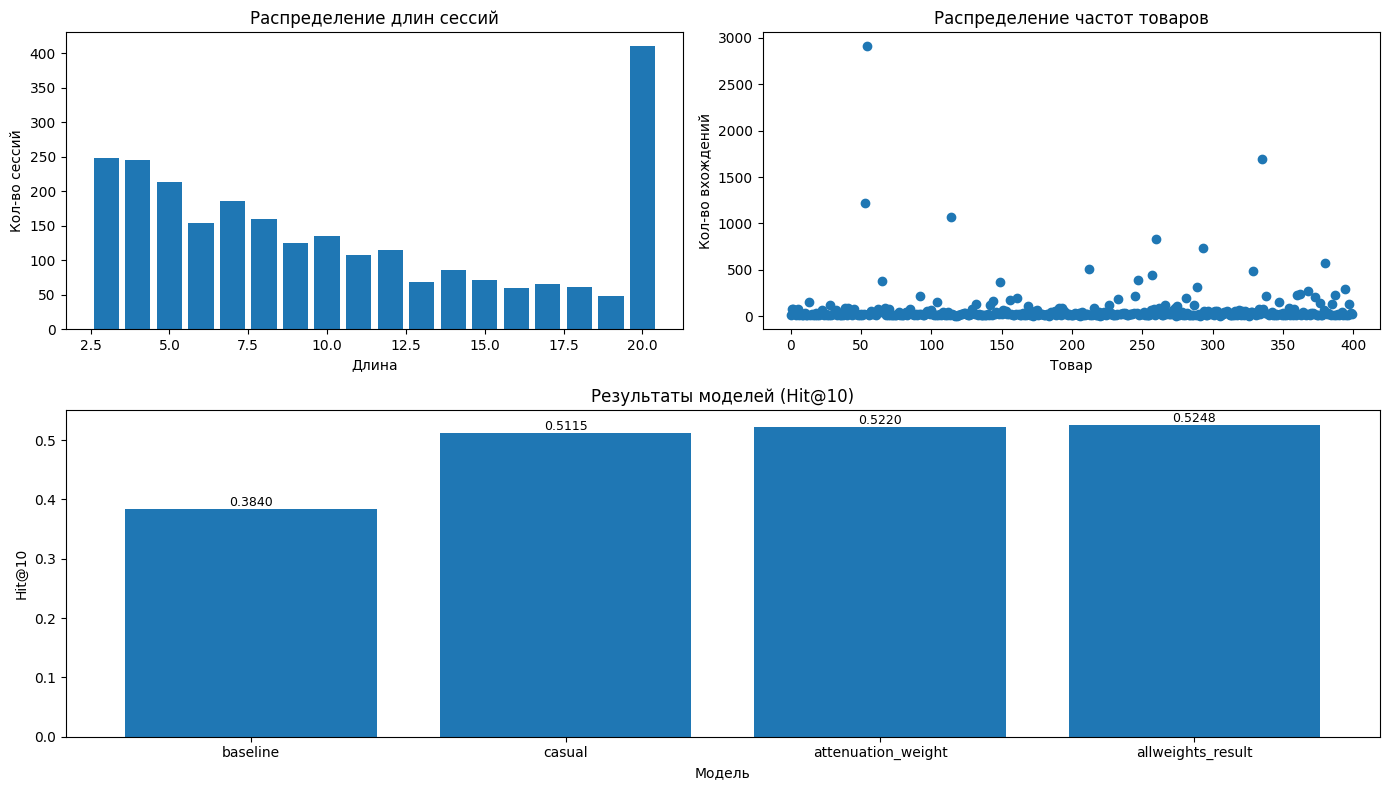

In [70]:
if isinstance(len_distr, dict):
    len_x = list(len_distr.keys())
    len_y = list(len_distr.values())
else:
    len_x = list(range(len(len_distr)))
    len_y = len_distr

model_names = ["baseline", "casual", "attenuation_weight", "allweights_result"]
model_values = []
for name in model_names:
    model_values.append(globals().get(name, np.nan))

plots = [
    {
        "x": len_x,
        "y": len_y,
        "title": "Распределение длин сессий",
        "xlabel": "Длина",
        "ylabel": "Кол-во сессий",
        "kind": "bar",
    },
    {
        "x": list(freq_distr.keys()),
        "y": list(freq_distr.values()),
        "title": "Распределение частот товаров",
        "xlabel": "Товар",
        "ylabel": "Кол-во вхождений",
        "kind": "scatter",
    },
    {
        "x": model_names,
        "y": model_values,
        "title": "Результаты моделей (Hit@10)",
        "xlabel": "Модель",
        "ylabel": "Hit@10",
        "kind": "bar",
    },
]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]

for ax, cfg in zip(axes, plots):
    kind = cfg.get("kind", "line")
    x = cfg.get("x")
    y = cfg.get("y")

    if kind == "scatter":
        ax.scatter(x, y)
    elif kind == "bar":
        bars = ax.bar(x, y)
        if cfg.get("title") == "Результаты моделей (Hit@10)":
            for b, v in zip(bars, y):
                ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(cfg.get("title", ""))
    ax.set_xlabel(cfg.get("xlabel", "X"))
    ax.set_ylabel(cfg.get("ylabel", "Y"))

plt.tight_layout()
plt.show()

### BASELINE
Возьмем просто 10 самых часто рекомендуемых и будем их предлгать всегда, при любых условиях

In [44]:
ids_freq: dict[int, int] = produce_freq_map(train)
top_10_freq = sorted(ids_freq.keys(), key=lambda x: ids_freq[x], reverse=True)[:10]
top_10_freq

[54, 335, 53, 114, 260, 293, 380, 212, 329, 257]

In [45]:
baseline = hit_at_k([top_10_freq]*len(test), test)
baseline

0.3840155945419103

### Тривиальное решение

Множество рекомендованных следующих id строится исходя из вероятности перехода куда-то из idn-1, если 10 элементов не набирается -> добираем из наиболее вероятных переходов по P(id | idn-x) пока не доберем

In [46]:
def simple_recommend(session: list[int], top_k: int = 10, item_idx: int = -1) -> list[int]:
    if not session:
        return []
    last_item = session[item_idx]
    if last_item not in GRAPH:
        return []
    next_items = GRAPH[last_item]
    sorted_next_items = sorted(next_items.items(), key=lambda x: x[1], reverse=True)
    return [item for item, _ in sorted_next_items[:top_k]]

In [47]:
def recommend(session: list[int], top_k: int = 10) -> list[int]:
    recs = simple_recommend(session, top_k)
    if len(recs) < top_k and len(session) >= 2:
        step_back_recs = simple_recommend(session, top_k, item_idx=-2)
        recs.extend(step_back_recs[:top_k - len(recs)])
    return recs[:top_k]

In [48]:
predictions = [recommend(train[i]) for i in range(len(train))]
casual = hit_at_k(predictions, test)
casual

0.5115009746588693

### Рубрика эксперименты


In [49]:
# мб a(затухание)P(id | idn-1, ..., id0) + bP(idn at least twice in session) + c(overall idn count in graph) = score(id, session)
# просто гридом или рандом

In [50]:
total: int = sum(ids_freq.values()) # общее число переходов
return_prob: dict[int, float] = {} # частота возврата к id в сессии >= 1 раза. число сессий с >1 вхождений id/общее число сессий с id
overall_id_share: dict[int, float] = {i:ids_freq[i] / total for i in ids_freq} # доля от всех переходов

for i in GRAPH.keys():
    _total: int = 0
    more_than_1: int = 0
    for session in train:
        c = session.count(i)
        if c >= 2:
            _total += 1
            more_than_1 += 1
        if c == 1:
            _total += 1
    return_prob[i] = more_than_1 / _total


In [51]:
def score_candidates(session: list[int], A: float, B: float, C: float) -> dict[int, float]:
    recs: dict[int, float] = {}
    coef: float = 1.0

    for i in range(len(session) - 1, -1, -1):
        item: int = session[i]
        if item not in GRAPH:
            continue

        for next_item, p in GRAPH[item].items():
            if next_item not in recs:
                recs[next_item] = 0.0
            recs[next_item] += p * coef
        coef *= A

    for item in recs.keys():
        recs[item] += B * return_prob.get(item, 0.0) + C * overall_id_share.get(item, 0.0)

    return recs

In [52]:
def evaluate(
    sessions: list[list[int]],
    true_items: list[int],
    A: float = 0.2,
    B: float = 0.0,
    C: float = 0.0,
    k: int = 10,
) -> float:
    recs = [
        [item for item, _ in sorted(score_candidates(session, A, B, C).items(), key=lambda kv: kv[1], reverse=True)[:k]] for session in sessions
    ]
    return hit_at_k(recs, true_items, k)

In [53]:
def hybrid_search(
    A_values=None,
    B_values=None,
    C_values=None,
    k_best: int = 5,
):
    if A_values is None:
        A_values = np.linspace(0.0, 0.25, 10)
    if B_values is None:
        B_values = [0.0]
    if C_values is None:
        C_values = [0.0]

    results = []
    for A in A_values:
        for B in B_values:
            for C in C_values:
                score = evaluate(train, test, A=float(A), B=float(B), C=float(C))
                results.append((score, float(A), float(B), float(C)))

    results.sort(reverse=True, key=lambda x: x[0])
    best = results[:k_best]
    return best, results

In [54]:
best, all_results = hybrid_search() 

In [55]:
all_results

[(0.5220272904483431, 0.027777777777777776, 0.0, 0.0),
 (0.52046783625731, 0.05555555555555555, 0.0, 0.0),
 (0.5189083820662768, 0.08333333333333333, 0.0, 0.0),
 (0.5177387914230019, 0.1388888888888889, 0.0, 0.0),
 (0.5169590643274854, 0.1111111111111111, 0.0, 0.0),
 (0.5157894736842106, 0.16666666666666666, 0.0, 0.0),
 (0.5130604288499026, 0.19444444444444442, 0.0, 0.0),
 (0.5107212475633528, 0.2222222222222222, 0.0, 0.0),
 (0.5103313840155945, 0.0, 0.0, 0.0),
 (0.5091617933723197, 0.25, 0.0, 0.0)]

In [56]:
w = best[0]
w

(0.5220272904483431, 0.027777777777777776, 0.0, 0.0)

In [64]:
attenuation_weight = w[0] 
attenuation_weight

0.5220272904483431

In [58]:
n = 10
A_vals = np.linspace(0.0, 0.25, n)
B_vals = np.linspace(0.0, 1, n)
C_vals = np.linspace(0.0, 1, n)
bestABC, all_resultsABC = hybrid_search(A_vals, B_vals, C_vals) # ~8min blya

In [59]:
bestABC

[(0.5247563352826511, 0.0, 0.0, 0.1111111111111111),
 (0.5235867446393763, 0.0, 0.0, 0.3333333333333333),
 (0.5231968810916179, 0.027777777777777776, 0.0, 0.1111111111111111),
 (0.5224171539961013, 0.027777777777777776, 0.0, 0.3333333333333333),
 (0.5220272904483431, 0.027777777777777776, 0.0, 0.0)]

In [63]:
allweights_result = bestABC[0][0]
allweights_result

0.5247563352826511